# 1. Introduction

Welcome to the first practical notebook for **27512 Big Data Methods, M2**. In this notebook, you will learn how to connect Python to modern language models, compare cloud-based and local NLP workflows, and create one simple text visualization.

By the end of this notebook, you will be able to:

- connect to Google Gemini and send your first prompt,
- use the OpenAI-compatible API pattern through OpenRouter,
- run local NLP pipelines with Hugging Face Transformers,
- apply basic prompt engineering and visualize text with a WordCloud.

**Prerequisites**

- Python 3.10 or 3.11 recommended
- `pip` available in your Python environment
- a Jupyter-capable environment, such as VS Code/Cursor notebooks or JupyterLab
- a Google account to create a Gemini API key
- an OpenRouter account to create an OpenRouter API key
- internet access for Gemini, OpenRouter, package installation, and the first Hugging Face model downloads
- enough disk space for local model files; Hugging Face models can take several hundred MB or more

**How to use this notebook**

Work through the notebook from top to bottom, cell by cell. Read the Markdown explanations carefully before running the next code cell. If a model download takes time, that is normal, especially for Hugging Face pipelines.

> 💡 Tip: This notebook is designed as self-study material. If something is unclear, read both the explanation and the code comments before moving on.

**Section summary:** You now know the goals, prerequisites, and workflow for this notebook.

# 2. Setup: Installing Packages

Before we can work with language models, we need a few Python packages. The installation cell below uses `pip` directly inside the notebook.

Here is what each package is for:

- `google-genai`: Google Python SDK for Gemini models
- `openai`: OpenAI-compatible client library, also useful for OpenRouter and other providers
- `transformers`: Hugging Face library for ready-made NLP pipelines and models
- `torch`: deep learning backend used by many transformer models
- `torchvision`: installed only to keep `torch` and `transformers` imports compatible in some environments
- `wordcloud`: creates word cloud visualizations from text
- `matplotlib`: plotting library for charts and visual output
- `pandas`: tabular data handling for review datasets and result tables

Some libraries used later, such as `os`, `json`, and `getpass`, are part of Python's standard library and do not need to be installed separately. Other dependencies, such as `numpy`, `tokenizers`, `safetensors`, and `huggingface_hub`, are installed automatically as dependencies of the packages above.

Run the next cell once. If the packages are already installed, `pip` will simply confirm that. On a fresh computer, the first installation can take several minutes, especially for `torch` and `torchvision`.

> Important: After running the setup cell, restart the notebook kernel before continuing. This avoids stale imports from older package versions.

In [2]:
# Use %pip in notebooks so packages install into the active kernel environment.
# First update packaging tools; this helps on fresh Python installations.
%pip install -U pip setuptools wheel

# Remove the old google package because it can conflict with google-genai.
%pip uninstall -y google

# Install torch and torchvision together so their versions stay compatible.
# Even though this notebook only uses text models, transformers may inspect torchvision during import.
%pip install -U google-genai openai transformers torch torchvision wordcloud matplotlib pandas

print("Setup complete. Please restart the kernel before running the next cells.")

  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
Using cached setuptools-82.0.1-py3-none-any.whl (1.0 MB)
  Attempting uninstall: setuptools
    Found existing installation: setuptools 81.0.0
    Uninstalling setuptools-81.0.0:
      Successfully uninstalled setuptools-81.0.0
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.11.0 requires setuptools<82, but you have setuptools 82.0.1 which is incompatible.


Note: you may need to restart the kernel to use updated packages.


  Using cached setuptools-81.0.0-py3-none-any.whl.metadata (6.6 kB)
Using cached setuptools-81.0.0-py3-none-any.whl (1.1 MB)
  Attempting uninstall: setuptools
    Found existing installation: setuptools 82.0.1
    Uninstalling setuptools-82.0.1:
      Successfully uninstalled setuptools-82.0.1
Note: you may need to restart the kernel to use updated packages.
Setup complete. Please restart the kernel before running the next cells.


**Section summary:** Your environment now has the core libraries for API access, local NLP pipelines, data handling, and visualization.

# 3. Getting Your API Keys

Large language model APIs require authentication. That means you need a personal API key so the provider knows who is making the request.

Why this matters:

- API keys unlock access to hosted models
- keys can be linked to quotas or billing
- keys must be protected like passwords

In notebooks, the safest beginner-friendly method is `getpass()`, which hides your input while typing.

## 3.1 Google Gemini (Free)

Follow these steps to create a Gemini API key:

1. Go to <https://aistudio.google.com/apikey>
2. Click **Create API Key**
3. Copy the generated key
4. **Important:** Never share your key publicly and never upload it to GitHub

The code below shows two patterns:

- interactive input with `getpass()` for notebooks,
- environment variables for scripts and production workflows.

> 💡 Tip: If you restart the notebook kernel, you will usually need to enter the key again.

In [1]:
import os
from getpass import getpass

# Option 1: Enter your key interactively (recommended for notebooks)
GEMINI_API_KEY = getpass("Enter your Google Gemini API key: ")

# Option 2: Set as environment variable (recommended for scripts)
# os.environ["GEMINI_API_KEY"] = "your-key-here"  # DON'T commit this!

## 3.2 OpenRouter (Free)

OpenRouter gives you access to many models through one API endpoint.

Follow these steps:

1. Go to <https://openrouter.ai>
2. Sign up with Google or GitHub
3. Open **API Keys** and create a new key
4. Explore free models on OpenRouter (the exact model IDs change over time; use the [free models collection](https://openrouter.ai/collections/free-models) or filter for `:free` on the [models page](https://openrouter.ai/models))

The next cell securely stores the key in a variable for this notebook session.

In [2]:
from getpass import getpass

# Enter your OpenRouter API key without displaying it on screen
OPENROUTER_API_KEY = getpass("Enter your OpenRouter API key: ")

**Section summary:** You now have a safe pattern for entering API keys in a notebook without hard-coding secrets.

# 4. Your First LLM Call: Google Gemini

In this section, you will make your first real request to a hosted large language model.

The general workflow is always similar:

1. create a client,
2. choose a model,
3. send a prompt,
4. inspect the response.

This pattern will appear again in many other APIs.

## 4.1 Basic Text Generation

The following code sends one short prompt to Gemini. Read it line by line:

- `genai.Client(...)` creates the connection object,
- `model="gemini-2.5-flash"` selects a fast Gemini model,
- `contents=...` contains the user prompt,
- `response.text` extracts the generated answer.

This is the simplest possible LLM workflow and a good template for your own experiments.

In [3]:
from google import genai

# Create a Gemini client using the API key you entered above
client = genai.Client(api_key=GEMINI_API_KEY)

# Send a simple prompt to the model and store the response
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents="Explain what Natural Language Processing is in 3 sentences."
)

# Print the plain text answer returned by the model
print(response.text)

Natural Language Processing (NLP) is a branch of artificial intelligence that empowers computers to understand, interpret, and generate human language. Its primary goal is to bridge the gap between human communication and computer comprehension, allowing machines to process and make sense of text and speech data. This enables applications like language translation, sentiment analysis, chatbots, and speech recognition, making human-computer interaction more natural and efficient.


## 4.2 System Prompts and Roles

A **system prompt** sets the overall behavior of the model before the user asks a question. You can use it to define style, tone, audience, or output expectations.

In the next example, we tell Gemini to act like a helpful NLP professor who explains concepts simply and uses examples.

This matters because the same question can lead to very different answers depending on how the model is instructed.

In [5]:
# Ask Gemini to answer with a specific teaching style
response = client.models.generate_content(
    model="gemini-2.5-flash",
    config=genai.types.GenerateContentConfig(
        system_instruction="You are a helpful NLP professor. Explain concepts simply with examples."
    ),
    contents="What is tokenization?"
)

# Display the generated explanation
print(response.text)

Ah, tokenization! This is one of the most fundamental concepts in Natural Language Processing (NLP), and it's where we start almost every journey into understanding text with computers.

Let's break it down simply.

### What is Tokenization?

Imagine you have a big, complex LEGO set, but all the pieces are still stuck together in a blob. You can't build anything until you separate them into individual, manageable bricks.

**Tokenization is essentially the process of breaking down a continuous piece of text into smaller, meaningful units called "tokens."**

These tokens are the building blocks that NLP models then work with.

---

### The Analogy: Your LEGO Bricks

*   **The Text (Blob of LEGOs):** "Hello, world! How are you doing today?"
*   **The Tokenizer (Your hands separating bricks):** The algorithm that does the splitting.
*   **The Tokens (Individual LEGO Bricks):** The separated units.

---

### What Can Be a Token?

The most common types of tokens are:

1.  **Words:** This is 

## 4.3 Temperature and Creativity

**Temperature** controls how predictable or creative a model's output will be.

- `0.0` means more focused and deterministic output
- `1.0` allows more variation and creativity

A lower temperature is often useful for factual or structured tasks. A higher temperature can be useful for brainstorming, rewriting, or creative text generation.

The next cell uses the same prompt twice so you can compare the effect directly.

In [ ]:
prompt = "Give a short explanation of stemming in NLP and include one example."

# Low temperature usually leads to a more stable and predictable answer
response_low = client.models.generate_content(
    model="gemini-2.5-flash",
    config=genai.types.GenerateContentConfig(temperature=0.0),
    contents=prompt
)

# Higher temperature often produces a more varied and creative answer
response_high = client.models.generate_content(
    model="gemini-2.5-flash",
    config=genai.types.GenerateContentConfig(temperature=1.0),
    contents=prompt
)

print("=== Temperature 0.0 ===")
print(response_low.text)
print("\n=== Temperature 1.0 ===")
print(response_high.text)

=== Temperature 0.0 ===
**Stemming** in NLP is the process of reducing words to their root or base form, often called a "stem." The goal is to group together words with similar meanings or inflections so they can be treated as the same word during analysis, typically by chopping off suffixes. The resulting "stem" might not always be a grammatically correct word itself.

**Example:**

The words "running," "runs," and "runner" would all be stemmed to "run."

=== Temperature 1.0 ===
**Stemming** in NLP is a technique used to reduce words to their base or root form, often called a "stem" or "root word." The main purpose is to group together words that have similar meanings but different grammatical endings, treating them as the same word for analysis. It typically works by removing suffixes (like -ing, -ed, -s, -es) from words.

**Example:**
The words "running," "runs," and "runner" would all be stemmed to the root word **"run."**


## 4.4 ✏️ Exercise

Ask Gemini to explain the difference between **AI**, **ML**, and **NLP**. Then repeat the task with temperature `0.0` and `0.8`.

Your goal is to observe:

- whether the wording changes,
- whether the structure changes,
- whether one answer feels clearer for learning.

> 💡 Tip: Keep the prompt identical in both runs so that temperature is the only major difference.

In [9]:
# Write your solution here.
prompt = "Explain the difference between AI, ML, and NLP."

# Low temperature usually leads to a more stable and predictable answer
response_low = client.models.generate_content(
    model="gemini-2.5-flash",
    config=genai.types.GenerateContentConfig(temperature=0.0),
    contents=prompt
)

# Higher temperature often produces a more varied and creative answer
response_high = client.models.generate_content(
    model="gemini-2.5-flash",
    config=genai.types.GenerateContentConfig(temperature=0.8),
    contents=prompt
)

print("=== Temperature 0.0 ===")
print(response_low.text)
print("\n=== Temperature 0.8 ===")
print(response_high.text)

=== Temperature 0.0 ===
Let's break down AI, ML, and NLP, as they are related but distinct concepts, often confused due to their overlapping nature. Think of it like a set of Russian nesting dolls: AI is the largest doll, ML is a smaller doll inside it, and NLP is a specific feature or application that often uses the ML doll.

---

### 1. Artificial Intelligence (AI)

*   **The Big Picture / The Goal:** AI is the broadest concept. It's the overarching field dedicated to creating machines that can perform tasks that typically require human intelligence.
*   **Scope:** It encompasses any technique that enables computers to mimic human cognitive functions like problem-solving, learning, reasoning, perception, understanding language, and even creativity.
*   **How it Works:** AI can be achieved through various methods, including:
    *   **Rule-based systems:** Explicitly programmed rules (e.g., "If X happens, then do Y").
    *   **Expert systems:** Systems that emulate the decision-makin

**Section summary:** You learned how to connect to Gemini, send prompts, use system instructions, and compare outputs with different temperature settings.

# 5. Universal API Pattern: OpenRouter

One of the most useful ideas in applied NLP is that many providers support similar API structures. If a provider is compatible with the OpenAI SDK, you can often reuse the same code pattern with only small changes.

This makes your code more portable and helps you compare models from different providers.

## 5.1 The OpenAI SDK, Works in Many Places

The `openai` Python library is not only for OpenAI models. If another service exposes an OpenAI-compatible API, you can often connect by changing the `base_url` and model name.

OpenRouter is a good example. In the code below:

- `base_url` points to the OpenRouter endpoint,
- `api_key` authenticates the request,
- `messages` contains the prompt in a chat-style format.

This message structure is widely used in LLM applications.

> Note: Free OpenRouter models can change or become temporarily rate-limited. If you see a 404, choose a current `:free` model from OpenRouter. If you see a 429, wait a little and try again. For broad compatibility with free models, this notebook puts instructions directly into the `user` message instead of using a separate `system` message.

In [11]:
from openai import OpenAI

# Create an OpenAI-compatible client that talks to OpenRouter instead of OpenAI
client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
)

# Send a standard chat completion request
response = client.chat.completions.create(
    model="openai/gpt-oss-120b:free",
    messages=[
        {
            "role": "user",
            "content": "You are a helpful assistant. What is sentiment analysis?",
        },
    ],
)

# Extract the text content from the first returned choice
print(response.choices[0].message.content)

**Sentiment analysis** (also called opinion mining) is a sub‑field of natural language processing (NLP) that automatically determines the emotional tone behind a piece of text. In other words, it tries to answer the question *“How does the writer feel?”* by classifying the expressed sentiment as, for example:

| Sentiment Category | Typical Meaning |
|--------------------|-----------------|
| **Positive**       | Praise, happiness, approval, excitement |
| **Negative**       | Disapproval, anger, sadness, criticism |
| **Neutral**        | Factual, informational, or no clear emotional slant |
| **Mixed/Other**    | Both positive and negative cues, sarcasm, or emotions not covered by the basic categories (e.g., fear, surprise) |

### How It Works
1. **Data Collection** – Gather text data (tweets, reviews, comments, etc.).
2. **Pre‑processing** – Clean the text (remove HTML tags, punctuation, stop‑words, tokenize, etc.).
3. **Feature Extraction** – Convert text into a machine‑readable fo

## 5.2 Trying Different Free Models

A major advantage of OpenRouter is easy model comparison. The code below sends the same prompt to three free models and stores the outputs in a pandas DataFrame.

Because free model endpoints can be busy, the code records an error message for a model instead of stopping the whole notebook. This keeps the comparison readable even when one provider is temporarily rate-limited.

Why do this?

- different models may be clearer, shorter, or more technical,
- some models may follow instructions better than others,
- model comparison helps you choose the right tool for a task.

In [15]:
import pandas as pd

comparison_prompt = "Explain named entity recognition in two concise sentences."
models = [
    "tencent/hy3-preview:free",
    "liquid/lfm-2.5-1.2b-instruct:free",
    "openai/gpt-oss-120b:free",
]

results = []

for model_name in models:
    try:
        response = client.chat.completions.create(
            model=model_name,
            messages=[
                {
                    "role": "user",
                    "content": f"You are a concise NLP tutor. {comparison_prompt}",
                },
            ],
        )
        answer = response.choices[0].message.content
    except Exception as error:
        answer = f"Could not get a response: {error}"

    results.append({
        "model": model_name,
        "response": answer,
    })

comparison_df = pd.DataFrame(results)
comparison_df

,model,response
0,tencent/hy3-preview:free,Named Entity Recognition (NER) is an NLP task ...
1,liquid/lfm-2.5-1.2b-instruct:free,Named entity recognition identifies and classi...
2,openai/gpt-oss-120b:free,Named Entity Recognition (NER) is the NLP task...


## 5.3 ✏️ Exercise

Pick your own NLP-related prompt. Then send it to three different models through OpenRouter.

Reflect on the outputs:

- Which answer is the most accurate?
- Which one is easiest to understand?
- Which one best follows your instructions?

Write one or two sentences below your code to justify your choice.

In [14]:
# Write your solution here.
import pandas as pd

comparison_prompt = "Explain NLP in two concise sentences."
models = [
    "tencent/hy3-preview:free",
    "nvidia/nemotron-3-super-120b-a12b:free",
    "openai/gpt-oss-120b:free",
]

results = []

for model_name in models:
    try:
        response = client.chat.completions.create(
            model=model_name,
            messages=[
                {
                    "role": "user",
                    "content": f"You are a concise NLP tutor. {comparison_prompt}",
                },
            ],
        )
        answer = response.choices[0].message.content
    except Exception as error:
        answer = f"Could not get a response: {error}"

    results.append({
        "model": model_name,
        "response": answer,
    })

comparison_df = pd.DataFrame(results)
comparison_df

,model,response
0,tencent/hy3-preview:free,Natural Language Processing (NLP) is an AI sub...
1,nvidia/nemotron-3-super-120b-a12b:free,Natural Language Processing (NLP) is a field o...
2,openai/gpt-oss-120b:free,Natural Language Processing (NLP) is a branch ...


**Section summary:** You saw how one SDK pattern can be reused across providers and how to compare different models with a consistent prompt.

# 6. Local Models: Hugging Face Pipelines

Cloud APIs are powerful, but they are not the only option. In many NLP workflows, local models are attractive because they are easy to test, often free to use, and do not require sending text to an external service.

Hugging Face pipelines provide a simple beginner-friendly interface for many standard NLP tasks.

> Note: This notebook only uses **text** models. Some `transformers` versions still inspect `torchvision` during import. The setup cell installs `torch` and `torchvision` together so their versions match. If `from transformers import pipeline` fails with a `torchvision` error, rerun the setup cell at the top and then **restart the kernel** before trying again.

## 6.1 Why Local Matters

Running models locally can be useful because of:

- **privacy**: sensitive text can stay on your machine,
- **cost**: many local models are free to run,
- **offline use**: some workflows can work without internet after the model is downloaded,
- **control**: you decide which model and task pipeline to use.

The tradeoff is that local models may be slower on weak hardware and often need an initial download.

## 6.2 Sentiment Analysis

Sentiment analysis predicts whether text expresses a positive, negative, or sometimes neutral opinion.

The pipeline below loads a ready-made sentiment model and applies it to one hotel review. This is a classic NLP task and a good first example because the code is very short compared with the amount of functionality you get.

In [16]:
from transformers import pipeline

# Load a ready-made sentiment analysis pipeline with an explicit text model
classifier = pipeline(
    "sentiment-analysis",
    model="distilbert/distilbert-base-uncased-finetuned-sst-2-english"
)

# Classify the sentiment of one review sentence
result = classifier("I love this hotel! The view was amazing.")

# Print the model prediction and confidence score
print(result)

f:\JOBs\Creatus\Code_oriented\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
f:\JOBs\Creatus\Code_oriented\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Hamidreza\.cache\huggingface\hub\models--distilbert--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an

[{'label': 'POSITIVE', 'score': 0.9998844861984253}]


## 6.3 Zero-Shot Classification

Zero-shot classification lets a model assign custom labels without task-specific retraining. You provide the labels you care about, and the model estimates which label best fits the text.

This is especially useful when you do not yet have a labeled dataset.

In [17]:
# Reuse the pipeline interface for a zero-shot classification task
classifier = pipeline(
    "zero-shot-classification",
    model="typeform/distilbert-base-uncased-mnli"
)

# Ask the model which category best matches the text
result = classifier(
    "The hotel restaurant served excellent Italian food.",
    candidate_labels=["food", "service", "room", "location"]
)

# Print the full result, including labels and scores
print(result)

f:\JOBs\Creatus\Code_oriented\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Hamidreza\.cache\huggingface\hub\models--typeform--distilbert-base-uncased-mnli. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1762.73it/s]


{'sequence': 'The hotel restaurant served excellent Italian food.', 'labels': ['location', 'food', 'service', 'room'], 'scores': [0.5163654088973999, 0.36820870637893677, 0.0699739009141922, 0.04545199126005173]}


## 6.4 Text Generation

Local text generation works with the same idea as hosted models: give the model a prompt and let it continue the text.

The example below uses `distilgpt2`, a smaller version of the classic GPT-2 model. It is not as strong as modern frontier models, but it is simple and useful for demonstration.

In [18]:
# Create a local text generation pipeline with a small GPT-2 style model
generator = pipeline("text-generation", model="distilgpt2")

# Generate a continuation from a short prompt
result = generator(
    "Natural Language Processing is",
    max_new_tokens=30,
    pad_token_id=generator.tokenizer.eos_token_id
)

# Print only the generated text from the first result item
print(result[0]["generated_text"])

f:\JOBs\Creatus\Code_oriented\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Hamidreza\.cache\huggingface\hub\models--distilgpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 76/76 [00:00<00:00, 1407.28it/s]
[transformers] Passing `generation_config` together 

Natural Language Processing is a process of processing language (FTP) files and algorithms. The process is called "processing for the language."









## 6.5 Named Entity Recognition

Named Entity Recognition, often shortened to **NER**, identifies entities such as people, organizations, and locations in text.

This is useful for information extraction, document analysis, and building structured datasets from unstructured text.

In [19]:
# Load a named entity recognition pipeline with an explicit text model
ner = pipeline(
    "ner",
    model="dslim/bert-base-NER",
    aggregation_strategy="simple"
)

# Analyze one sentence and return grouped entity spans
result = ner("Paul Pronobis teaches NLP at the Free University of Bozen in Italy.")

# Print each detected entity in a readable format
for entity in result:
    print(f"{entity['word']} -> {entity['entity_group']} ({entity['score']:.2f})")

f:\JOBs\Creatus\Code_oriented\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Hamidreza\.cache\huggingface\hub\models--dslim--bert-base-NER. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1617.89it/s]
[transformers] BertForTokenClassificatio

Paul Pronobis -> PER (1.00)
NLP -> ORG (0.73)
Free University of Bozen -> ORG (0.95)
Italy -> LOC (1.00)


## 6.6 ✏️ Exercise

In the next code cell, classify 10 hotel reviews with the sentiment-analysis pipeline and display the result as a pandas DataFrame.

You can use the hotel review dataset created later in this notebook, or build a short list manually.

> 💡 Tip: Create one list with review texts, then pass the list into the pipeline so you can classify multiple texts at once.

In [21]:
# Write your solution here.

import pandas as pd

# Create a small self-contained dataset with ratings and review text
hotel_reviews = [
    {"rating": 5, "review_text": "The hotel room was spotless, the staff were welcoming, and breakfast was excellent."},
    {"rating": 4, "review_text": "Great location near the train station, comfortable bed, and fast check-in."},
    {"rating": 2, "review_text": "The room smelled damp and the Wi-Fi kept disconnecting during my stay."},
    {"rating": 3, "review_text": "Nice lobby and friendly staff, but the bathroom was very small."},
    {"rating": 5, "review_text": "Amazing rooftop view, quiet room, and one of the best hotel breakfasts I have had."},
    {"rating": 1, "review_text": "Terrible experience, dirty sheets, rude service, and noisy guests all night."},
    {"rating": 4, "review_text": "Clean room, good air conditioning, and helpful recommendations from reception."},
    {"rating": 2, "review_text": "Breakfast was limited, the elevator was broken, and the room felt outdated."},
    {"rating": 5, "review_text": "Excellent value for money, modern design, and very reliable internet."},
    {"rating": 3, "review_text": "The hotel was fine overall, but the check-out process took too long."},
    {"rating": 4, "review_text": "Lovely garden area, tasty dinner, and easy parking right outside the hotel."},
    {"rating": 1, "review_text": "The air conditioner did not work, the room was hot, and nobody fixed the issue."},
    {"rating": 5, "review_text": "Wonderful spa, spacious room, and professional staff made this a relaxing stay."},
    {"rating": 2, "review_text": "Good location, but the walls were thin and I could hear everything from next door."},
    {"rating": 4, "review_text": "Very good breakfast buffet, clean bathroom, and smooth online booking process."},
    {"rating": 3, "review_text": "The room was acceptable and the hotel was quiet, but nothing really stood out."},
    {"rating": 5, "review_text": "Fantastic service from the front desk and a beautiful room with a balcony."},
    {"rating": 2, "review_text": "The mattress was uncomfortable and the shower water was barely warm."},
    {"rating": 4, "review_text": "Pleasant stay, helpful staff, and convenient access to the city center."},
    {"rating": 1, "review_text": "My reservation was missing, the room was not ready, and support was unhelpful."}
]

df = pd.DataFrame(hotel_reviews)
df.head(10)

,rating,review_text
0,5,"The hotel room was spotless, the staff were we..."
1,4,"Great location near the train station, comfort..."
2,2,The room smelled damp and the Wi-Fi kept disco...
3,3,"Nice lobby and friendly staff, but the bathroo..."
4,5,"Amazing rooftop view, quiet room, and one of t..."
5,1,"Terrible experience, dirty sheets, rude servic..."
6,4,"Clean room, good air conditioning, and helpful..."
7,2,"Breakfast was limited, the elevator was broken..."
8,5,"Excellent value for money, modern design, and ..."
9,3,"The hotel was fine overall, but the check-out ..."


**Section summary:** You learned how to run local transformer pipelines for sentiment analysis, zero-shot classification, text generation, and named entity recognition.

# 7. Bonus: WordCloud Visualization

A WordCloud is a quick and intuitive way to explore text data. Words that appear more often are displayed more prominently. It is not a deep analysis method, but it is excellent for an initial visual impression.

This section uses a small hotel review dataset embedded directly in the notebook. That means the notebook remains self-contained even if no external CSV file is available.

## 7.1 Create a Small Hotel Review Dataset

The next cell creates a pandas DataFrame with 20 hotel reviews and ratings. Embedding the data directly in the notebook is useful for teaching because every student can run the examples immediately.

Later, you could replace this with a larger CSV file from a real project.

In [22]:
import pandas as pd

# Create a small self-contained dataset with ratings and review text
hotel_reviews = [
    {"rating": 5, "review_text": "The hotel room was spotless, the staff were welcoming, and breakfast was excellent."},
    {"rating": 4, "review_text": "Great location near the train station, comfortable bed, and fast check-in."},
    {"rating": 2, "review_text": "The room smelled damp and the Wi-Fi kept disconnecting during my stay."},
    {"rating": 3, "review_text": "Nice lobby and friendly staff, but the bathroom was very small."},
    {"rating": 5, "review_text": "Amazing rooftop view, quiet room, and one of the best hotel breakfasts I have had."},
    {"rating": 1, "review_text": "Terrible experience, dirty sheets, rude service, and noisy guests all night."},
    {"rating": 4, "review_text": "Clean room, good air conditioning, and helpful recommendations from reception."},
    {"rating": 2, "review_text": "Breakfast was limited, the elevator was broken, and the room felt outdated."},
    {"rating": 5, "review_text": "Excellent value for money, modern design, and very reliable internet."},
    {"rating": 3, "review_text": "The hotel was fine overall, but the check-out process took too long."},
    {"rating": 4, "review_text": "Lovely garden area, tasty dinner, and easy parking right outside the hotel."},
    {"rating": 1, "review_text": "The air conditioner did not work, the room was hot, and nobody fixed the issue."},
    {"rating": 5, "review_text": "Wonderful spa, spacious room, and professional staff made this a relaxing stay."},
    {"rating": 2, "review_text": "Good location, but the walls were thin and I could hear everything from next door."},
    {"rating": 4, "review_text": "Very good breakfast buffet, clean bathroom, and smooth online booking process."},
    {"rating": 3, "review_text": "The room was acceptable and the hotel was quiet, but nothing really stood out."},
    {"rating": 5, "review_text": "Fantastic service from the front desk and a beautiful room with a balcony."},
    {"rating": 2, "review_text": "The mattress was uncomfortable and the shower water was barely warm."},
    {"rating": 4, "review_text": "Pleasant stay, helpful staff, and convenient access to the city center."},
    {"rating": 1, "review_text": "My reservation was missing, the room was not ready, and support was unhelpful."}
]

df = pd.DataFrame(hotel_reviews)
df.head()

,rating,review_text
0,5,"The hotel room was spotless, the staff were we..."
1,4,"Great location near the train station, comfort..."
2,2,The room smelled damp and the Wi-Fi kept disco...
3,3,"Nice lobby and friendly staff, but the bathroo..."
4,5,"Amazing rooftop view, quiet room, and one of t..."


## 7.2 Simple Preprocessing for a WordCloud

Before generating the WordCloud, we do a small amount of preprocessing:

- convert all text to lowercase,
- split the text into tokens,
- remove very common stopwords such as `the`, `and`, and `was`,
- join the remaining words back into one text string.

This adapted workflow is inspired by the WordCloud example from the earlier airline preprocessing notebook, but simplified for our hotel review scenario.

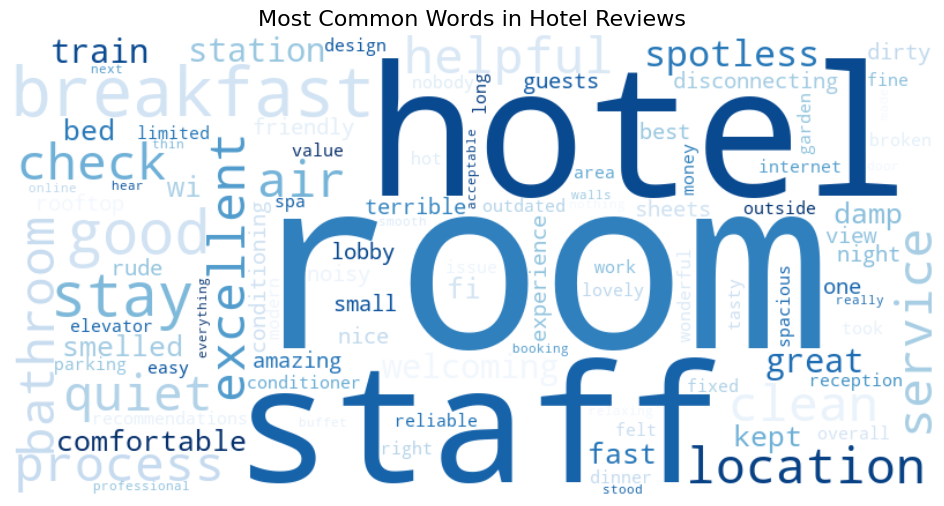

In [23]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Define a simple stopword list for quick preprocessing
custom_stopwords = {
    "the", "and", "was", "were", "with", "this", "that", "from", "have",
    "had", "very", "but", "too", "all", "our", "their", "they", "into",
    "near", "my", "out", "not"
}

# Combine all review texts into one long string and lowercase it
all_text = " ".join(df["review_text"]).lower()

# Keep only alphabetic tokens and remove stopwords
clean_tokens = [
    token.strip(".,!?:;()\"'-")
    for token in all_text.split()
    if token.strip(".,!?:;()\"'-") and token.strip(".,!?:;()\"'-") not in custom_stopwords
]

# Rebuild the cleaned text for the WordCloud input
clean_text = " ".join(clean_tokens)

# Generate a WordCloud similar to the earlier airline example
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100,
    colormap="Blues"
).generate(clean_text)

# Plot the WordCloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Hotel Reviews", fontsize=16)
plt.show()

**Section summary:** You created a small review dataset, applied simple preprocessing, and visualized common words with a WordCloud.

# 8. Prompt Engineering Basics

Prompt engineering means designing your input so the model gives a more useful output. Better prompts often improve quality without changing the model itself.

This section introduces a few practical rules you can apply immediately.

## 8.1 What Makes a Good Prompt?

Four simple rules:

1. **Be specific** about the task
2. **Provide context** so the model knows the domain or audience
3. **Give examples** when the format or style matters
4. **Define the output format** if you want bullet points, JSON, labels, or a table

The next cell compares a vague prompt with an improved one.

In [ ]:
bad_prompt = "Analyze this review."

good_prompt = """
You are an NLP teaching assistant.
Analyze the following hotel review.
Return:
1. sentiment label,
2. one-sentence justification,
3. two important keywords.


Review: 'The breakfast was amazing but the room was too small.'
"""

print("Bad prompt:\n")
print(bad_prompt)
print("\n" + "=" * 60 + "\n")
print("Good prompt:\n")
print(good_prompt)

Bad prompt:

Analyze this review.


Good prompt:


You are an NLP teaching assistant.
Analyze the following hotel review.
Return:
1. sentiment label,
2. one-sentence justification,
3. two important keywords.

Review: 'The breakfast was amazing but the room was too small.'



## 8.2 Few-Shot Prompting

Few-shot prompting means you include small examples inside the prompt. These examples show the model what a good answer looks like.

This technique is helpful when you want consistent labels, style, or formatting.

In [2]:
prompt = """Classify the sentiment of each review as POSITIVE, NEGATIVE, or NEUTRAL.

Examples:
- "Great hotel, wonderful staff!" → POSITIVE
- "Terrible experience, dirty room." → NEGATIVE
- "It was okay, nothing special." → NEUTRAL

Now classify:
- "The breakfast was amazing but the room was too small."
"""

print(prompt)

Classify the sentiment of each review as POSITIVE, NEGATIVE, or NEUTRAL.

Examples:
- "Great hotel, wonderful staff!" → POSITIVE
- "Terrible experience, dirty room." → NEGATIVE
- "It was okay, nothing special." → NEUTRAL

Now classify:
- "The breakfast was amazing but the room was too small."



## 8.3 Structured Output (JSON)

In many real applications, plain text is not enough. You may want a model to return structured data that can be processed automatically.

A common pattern is to ask for JSON and then parse the result with Python.

The next cell demonstrates the parsing side using a mock JSON string. In a real API call, the string would come from the model response.

In [3]:
import json

# Example of a JSON-formatted model response stored as a string
json_response = """
{
  "hotel_name": "Grand Lakeside Hotel",
  "rating": 4,
  "pros": ["great breakfast", "friendly staff"],
  "cons": ["small room"]
}
"""

# Convert the JSON string into a Python dictionary
parsed = json.loads(json_response)

# Inspect the parsed structured output
print(parsed)
print(parsed["pros"])

{'hotel_name': 'Grand Lakeside Hotel', 'rating': 4, 'pros': ['great breakfast', 'friendly staff'], 'cons': ['small room']}
['great breakfast', 'friendly staff']


## 8.4 ✏️ Exercise

Use few-shot prompting to extract structured data from 5 review texts.

Your JSON output should include:

- `hotel_name`
- `rating`
- `pros`
- `cons`

If a review text does not mention one of these clearly, make a reasonable guess and explain your prompt design choices in a short note below your code.

> 💡 Tip: Start by selecting 5 reviews from `df["review_text"]` and then build one prompt that asks for a JSON list.

In [6]:
# Write your solution here.

# Example of a JSON-formatted model response stored as a string
json_response = """
{
  "hotel_name": "Hotel Hilton",
  "rating": 5,
  "pros": ["great dinner"],
  "cons": ["small bathroom"]
}
"""

# Convert the JSON string into a Python dictionary
parsed = json.loads(json_response)

# Inspect the parsed structured output
print(parsed)
print(parsed["pros"])

{'hotel_name': 'Hotel Hilton', 'rating': 5, 'pros': ['great dinner'], 'cons': ['small bathroom']}
['great dinner']


**Section summary:** You learned four prompt design rules, saw a few-shot example, and practiced the idea of structured JSON output.

# 9. When to Use What? (Decision Guide)

There is no single best NLP tool for every situation. The right choice depends on your task, privacy needs, cost constraints, and whether internet access is available.

Use the table below as a quick decision guide.

In [7]:
import pandas as pd

# Build a decision table that compares the main tool choices in this notebook
decision_table = pd.DataFrame([
    {
        "Tool": "Google Gemini",
        "Best for": "General LLM tasks, long context",
        "Cost": "Free tier",
        "Speed": "Fast",
        "Needs Internet?": "Yes"
    },
    {
        "Tool": "OpenRouter",
        "Best for": "Model comparison, flexibility",
        "Cost": "Free models available",
        "Speed": "Varies",
        "Needs Internet?": "Yes"
    },
    {
        "Tool": "HuggingFace Pipeline",
        "Best for": "Classification, NER, local inference",
        "Cost": "Free",
        "Speed": "Depends on model",
        "Needs Internet?": "No after download"
    }
])

# Display the decision guide as a DataFrame
decision_table

,Tool,Best for,Cost,Speed,Needs Internet?
0,Google Gemini,"General LLM tasks, long context",Free tier,Fast,Yes
1,OpenRouter,"Model comparison, flexibility",Free models available,Varies,Yes
2,HuggingFace Pipeline,"Classification, NER, local inference",Free,Depends on model,No after download


**Section summary:** You now have a practical overview of when hosted APIs and local pipelines are most appropriate.

# 10. Summary and Next Steps

You have completed the first notebook in this series. Here is what you covered:

- installing key NLP and LLM libraries,
- creating and protecting API keys,
- sending prompts to Google Gemini,
- using the OpenAI-compatible pattern with OpenRouter,
- running local Hugging Face pipelines,
- generating a WordCloud from review text,
- improving prompts with specificity, examples, and structured output.

Useful documentation:

- Gemini docs: <https://ai.google.dev/gemini-api/docs>
- OpenRouter docs: <https://openrouter.ai/docs/quickstart>
- Hugging Face Transformers docs: <https://huggingface.co/docs/transformers/index>

In the next lecture, we will go deeper into **text classification and sentiment analysis** with more live and hands-on examples.

> 💡 Tip: Before the next class, try changing the prompts and model names in this notebook so you can build intuition through experimentation.

**Section summary:** You now have a full first workflow for connecting to LLMs, comparing models, using local NLP tools, and preparing for the next lecture.